## Working with TiTiler-EoPF - Single Item (ZARR datastore)

This notebook demonstrates how to use the TiTiler-EoPF service to visualize a single Item (STAC) of EOPF Zarr datastore.


In [1]:
import json
import httpx2 as httpx
from folium import Map, TileLayer

%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


In [ ]:
# Start services
!docker compose up api -d

In [5]:
titiler_endpoint = "http://127.0.0.1:8000"

In [6]:
r = httpx.get(f"{titiler_endpoint}/_mgmt/health")
print(r.json())

{'status': 'UP', 'versions': {'titiler': '0.10.1', 'rasterio': '1.5.1', 'gdal': '3.12.4', 'proj': '9.8.1', 'geos': '3.14.1', 'xarray': '2026.7.0', 'zarr': '3.3.0'}}


### Conformances

In [7]:
r = httpx.get(f"{titiler_endpoint}/conformance").json()
print(json.dumps(r, indent=4))

{
    "conformsTo": [
        "http://www.opengis.net/spec/ogcapi-common-1/1.0/conf/core",
        "http://www.opengis.net/spec/ogcapi-common-1/1.0/conf/html",
        "http://www.opengis.net/spec/ogcapi-common-1/1.0/conf/json",
        "http://www.opengis.net/spec/ogcapi-common-1/1.0/conf/landing-page",
        "http://www.opengis.net/spec/ogcapi-common-1/1.0/conf/oas30",
        "http://www.opengis.net/spec/ogcapi-tiles-1/1.0/conf/core",
        "http://www.opengis.net/spec/ogcapi-tiles-1/1.0/conf/jpeg",
        "http://www.opengis.net/spec/ogcapi-tiles-1/1.0/conf/png",
        "http://www.opengis.net/spec/ogcapi-tiles-1/1.0/conf/tiff",
        "http://www.opengis.net/spec/ogcapi-tiles-1/1.0/conf/tileset",
        "http://www.opengis.net/spec/ogcapi-tiles-1/1.0/conf/tilesets-list",
        "https://www.opengis.net/spec/ogcapi-maps-1/1.0/conf/core",
        "https://www.opengis.net/spec/ogcapi-maps-1/1.0/conf/crs",
        "https://www.opengis.net/spec/ogcapi-maps-1/1.0/conf/jpeg",
  

# Find Item ID

Let's find one Item to visizualize. We can use the [EOPF STAC API](https://api.explorer.eopf.copernicus.eu/stac) to find an Item ID.

In [26]:
collection_id = "sentinel-2-l2a"
bbox = [11.393460776835221, 41.42010137184542, 12.466572328262494, 42.426911995973605]
date = "2026-01-17T00:00:00Z/2026-08-01T23:59:59Z"

r = httpx.get(
    "https://api.explorer.eopf.copernicus.eu/stac/search",
    params={
        "collections": [collection_id],
        "bbox": ",".join(map(str, bbox)),
        "datetime": date,
    },
).json()
print("Found :", r["numberMatched"])

item = r["features"][0]
item_id = item["id"]
print("Using item: ", item_id)

Found : 460
Using item:  S2B_MSIL2A_20260731T100559_N0512_R022_T33TTG_20260731T142842


## Item Info

In [27]:
# List Availables assets for the item
r = httpx.get(
    f"{titiler_endpoint}/collections/{collection_id}/items/{item_id}/assets",
    timeout=20,
).json()

print(json.dumps(r, indent=4))

[
    "AOT_10m",
    "SCL_20m",
    "WVP_10m",
    "reflectance"
]


In [33]:
# Get Info for the `reflectance` assets
r = httpx.get(
    f"{titiler_endpoint}/collections/{collection_id}/items/{item_id}/info",
    params={"assets": "reflectance"},
    timeout=20,
).json()

print("List of group/variable: ", list(r))
print(json.dumps(r["reflectance_root_b01"], indent=4))

List of group/variable:  ['reflectance_root_b01', 'reflectance_root_b02', 'reflectance_root_b03', 'reflectance_root_b04', 'reflectance_root_b05', 'reflectance_root_b06', 'reflectance_root_b07', 'reflectance_root_b08', 'reflectance_root_b09', 'reflectance_root_b11', 'reflectance_root_b12', 'reflectance_root_b8a']
{
    "bounds": [
        199990.0,
        4590230.0,
        309790.0,
        4700030.0
    ],
    "crs": "http://www.opengis.net/def/crs/EPSG/0/32633",
    "band_metadata": [
        [
            "b1",
            {}
        ]
    ],
    "band_descriptions": [
        [
            "b1",
            "b01"
        ]
    ],
    "dtype": "float32",
    "nodata_type": "None",
    "name": "b01",
    "count": 1,
    "width": 5490,
    "height": 5490,
    "dimensions": [
        "y",
        "x"
    ],
    "attrs": {
        "long_name": "BOA reflectance from MSI acquisition at spectral band 01 443 nm",
        "units": "1",
        "zarr_conventions": [
            {
           

In [56]:
# Get Info for specific variable within the `reflectance` assets
r = httpx.get(
    f"{titiler_endpoint}/collections/{collection_id}/items/{item_id}/info",
    params={"assets": "reflectance|bands=b01,b02"},
    timeout=20,
).json()

print("List of variable: ", list(r))
print(json.dumps(r["reflectance|bands=['b01','b02']_b01"], indent=4))

List of variable:  ["reflectance|bands=['b01','b02']_b01", "reflectance|bands=['b01','b02']_b02"]
{
    "bounds": [
        199990.0,
        4590230.0,
        309790.0,
        4700030.0
    ],
    "crs": "http://www.opengis.net/def/crs/EPSG/0/32633",
    "band_metadata": [
        [
            "b1",
            {}
        ]
    ],
    "band_descriptions": [
        [
            "b1",
            "b01"
        ]
    ],
    "dtype": "float32",
    "nodata_type": "None",
    "name": "b01",
    "count": 1,
    "width": 5490,
    "height": 5490,
    "dimensions": [
        "y",
        "x"
    ],
    "attrs": {
        "long_name": "BOA reflectance from MSI acquisition at spectral band 01 443 nm",
        "units": "1",
        "zarr_conventions": [
            {
                "schema_url": "https://raw.githubusercontent.com/zarr-conventions/spatial/refs/tags/v1/schema.json",
                "spec_url": "https://github.com/zarr-conventions/spatial/blob/v1/README.md",
                "

## Get True Color Preview for the item

In [57]:
r = httpx.get(
    f"{titiler_endpoint}/collections/{collection_id}/items/{item_id}/preview.png",
    params={
        "assets": "reflectance|bands=b04,b03,b02",
        "rescale": "0,0.6",
    },
    timeout=20,
)
print(r.headers)

Headers({'date': 'Thu, 03 Sep 2026 11:48:18 GMT', 'server': 'uvicorn', 'content-bbox': '200040.0,4590180.0,309840.0,4699980.0', 'content-crs': '<http://www.opengis.net/def/crs/EPSG/0/32633>', 'content-length': '628417', 'content-type': 'image/png', 'cache-control': 'public, max-age=3600', 'server-timing': 'total;dur=1184.48'})


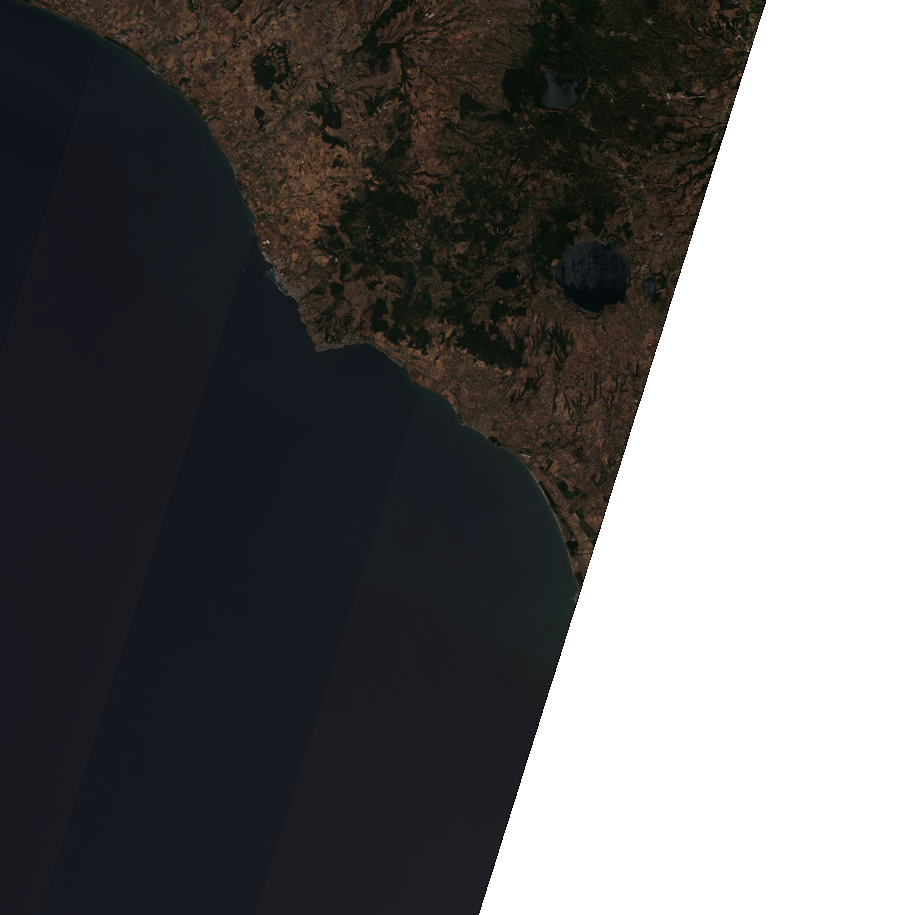

In [58]:
from IPython.display import Image

Image(r.content)

## Display True Color tiles

In [67]:
r = httpx.get(
    f"{titiler_endpoint}/collections/{collection_id}/items/{item_id}/WebMercatorQuad/tilejson.json",
    params={
        "assets": "reflectance|bands=b04,b03,b02",
        "rescale": "0,0.6",
        "tilesize": 256,
    },
    timeout=20,
).json()
print(r)
bounds = r["bounds"]
m = Map(
    location=((bounds[1] + bounds[3]) / 2, (bounds[0] + bounds[2]) / 2), zoom_start=8
)

TileLayer(tiles=r["tiles"][0], opacity=1, attr="ESA EoPF").add_to(m)
m

{'tilejson': '3.0.0', 'version': '1.0.0', 'scheme': 'xyz', 'tiles': ['http://127.0.0.1:8000/collections/sentinel-2-l2a/items/S2B_MSIL2A_20260731T100559_N0512_R022_T33TTG_20260731T142842/tiles/WebMercatorQuad/{z}/{x}/{y}?assets=reflectance%7Cbands%3Db04%2Cb03%2Cb02&rescale=0%2C0.6&tilesize=256'], 'minzoom': 0, 'maxzoom': 24, 'bounds': [11.354954233772318, 41.407726190110715, 12.472898075726283, 42.42377705833401], 'center': [11.913926154749301, 41.915751624222366, 0], 'raster_layers': {}}
